# Linear Regression: A Comprehensive Guide

Linear Regression is one of the fundamental algorithms in machine learning used for predictive analysis. It's a supervised learning algorithm that helps us understand the relationship between dependent (target) and independent (features) variables.

In this notebook, we'll cover:
1. Basic concepts of Linear Regression
2. Data preparation and visualization
3. Model implementation
4. Using scikit-learn for Linear Regression
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

This notebook shows how to use linear regression, a basic method for predicting numbers.

Imagine you want to predict someone's height based on their age. You collect data (age and height) and draw a straight line that best fits all the points. This line helps you guess the height for any age.

Here's what happens in the code below:
1. We create some example data that follows a simple rule (like height = 2 × age + 1, but with some random noise).
2. We use a computer to find the best straight line that fits this data.
3. We show how to do this step-by-step (from scratch) and also using a popular library called scikit-learn.
4. We check how good our line is at predicting new values.

In short: The code teaches you how to use a straight line to make predictions from data, and how to check if your predictions are accurate.

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'python -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip.exe')
if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

To understand linear regression, let's create a simple dataset with a clear linear relationship. We'll add some noise to make it more realistic.

The relationship will follow the equation: y = 2x + 1 + noise

This means:
- The true slope (coefficient) is 2
- The true intercept is 1
- We'll add random noise to simulate real-world data

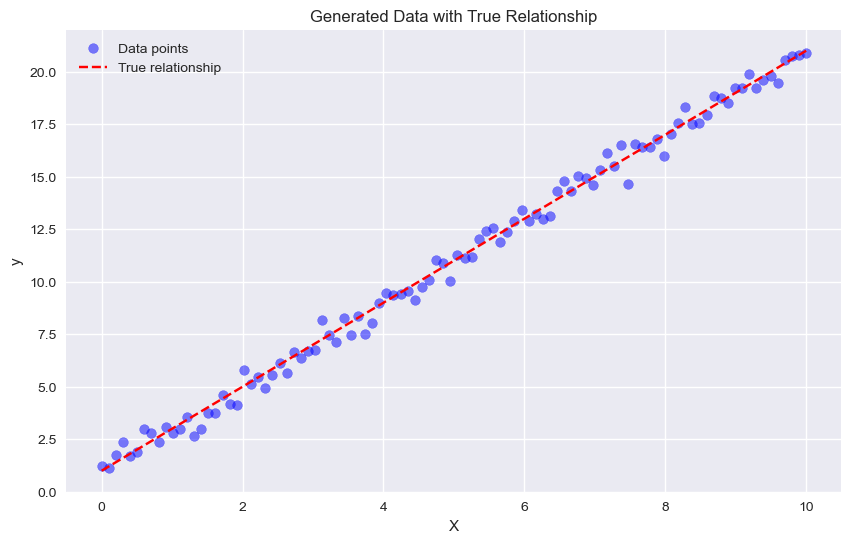

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate X values
X = np.linspace(0, 10, 100).reshape(-1, 1)

# Generate y values with some noise
y = 2 * X + 1 + np.random.normal(0, 0.5, X.shape)

# Create a DataFrame for better visualization
data = pd.DataFrame({
    'X': X.flatten(),
    'y': y.flatten()
})

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.plot(X, 2*X + 1, color='red', linestyle='--', label='True relationship')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data with True Relationship')
plt.legend()
plt.grid(True)
plt.show()

# 3. Implementing Linear Regression

Before using scikit-learn, let's implement linear regression to understand the underlying mathematics.

Key concepts:
1. **Linear Relationship**: y = mx + b
   - m: slope (coefficient)
   - b: y-intercept

2. **Cost Function**: Mean Squared Error (MSE)
   - Measures how well our line fits the data
   - Lower MSE means better fit

3. **Gradient Descent**:
   - Algorithm to find the optimal parameters
   - Updates parameters iteratively to minimize the cost function

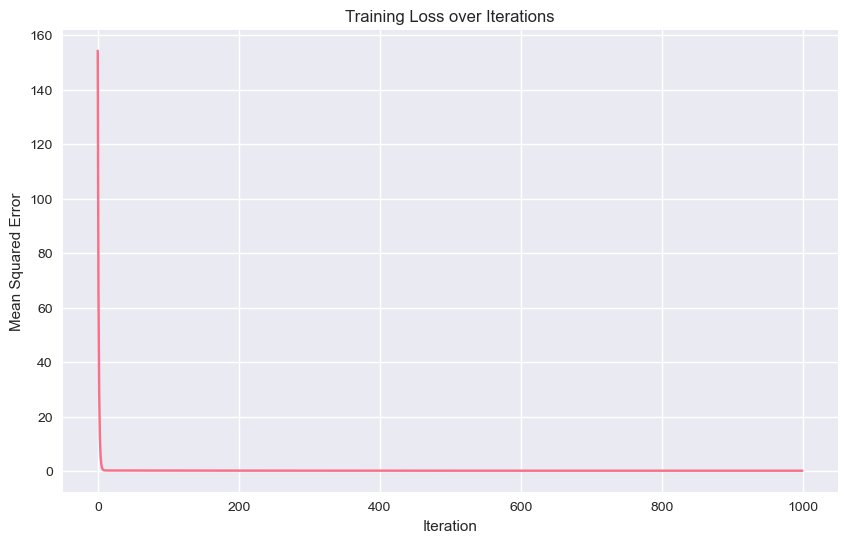

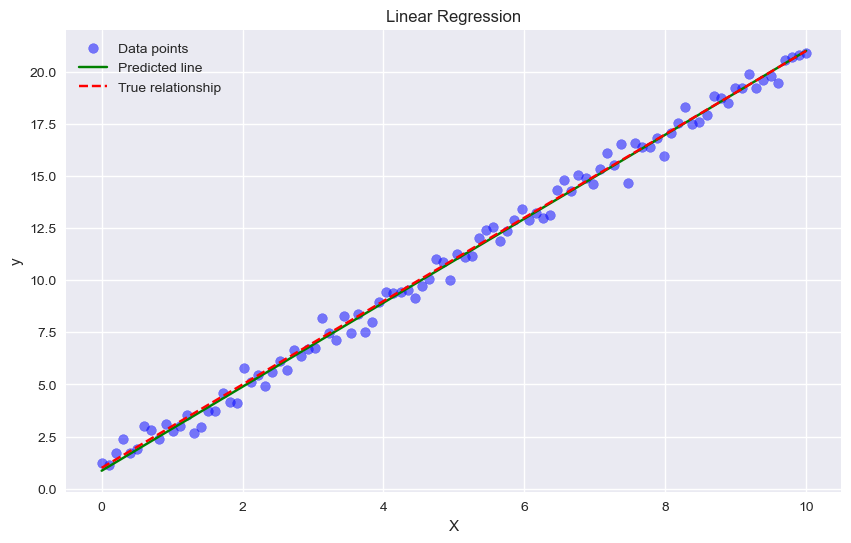

In [4]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.history = {'loss': []}
        
    def fit(self, X, y):
        # Flatten y to ensure it's a 1D array
        y = y.flatten()
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Compute and store loss
            loss = np.mean((y_predicted - y) ** 2)
            self.history['loss'].append(loss)
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train the model
model_scratch = LinearRegressionScratch(learning_rate=0.01, n_iterations=1000)
model_scratch.fit(X, y)

# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(model_scratch.history['loss'])
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.plot(X, model_scratch.predict(X), color='green', label='Predicted line')
plt.plot(X, 2*X + 1, color='red', linestyle='--', label='True relationship')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

### What is the benefit of knowing training loss over iterations?

The plot of the training loss over iterations is a powerful diagnostic tool. It gives you a window into how the model is learning over time. Here are the key benefits:

*   **Verifying Learning**: The most basic check is to see if the loss is actually decreasing. If it is, your model is learning. If it's flat or increasing, something is wrong.

*   **Tuning the Learning Rate**:
    *   **Too Slow**: If the loss decreases very slowly, your learning rate might be too small. The model is learning, but it will take a very long time to converge.
    *   **Too Fast / Unstable**: If the loss fluctuates wildly, or even increases, your learning rate is likely too large. The model is overshooting the optimal solution with each step.

*   **Identifying Convergence**: When the loss curve flattens out and stops decreasing, it means the model has converged. This tells you that further training (more iterations) is unlikely to improve the model. This helps you choose the right number of iterations to train for, saving computational resources.

*   **Debugging the Model**: A strange-looking loss curve can be the first sign of a problem. For example, a sudden spike might indicate a problem with a batch of data, or a consistently high loss might mean the model is too simple to capture the patterns in the data.

In short, watching the training loss is like watching a patient's vital signs during surgery. It tells you if things are going as planned and helps you intervene if they are not.

# 4. Using Scikit-learn's Linear Regression

Now let's use scikit-learn's implementation of Linear Regression. The advantages of using scikit-learn include:
1. Optimized implementation
2. Consistent API
3. Built-in cross-validation and evaluation metrics
4. Scalability for larger datasets

Coefficient (slope): 2.0060
Intercept: 0.9099

Model Performance:
R² Score: 0.9953
Mean Squared Error: 0.1555


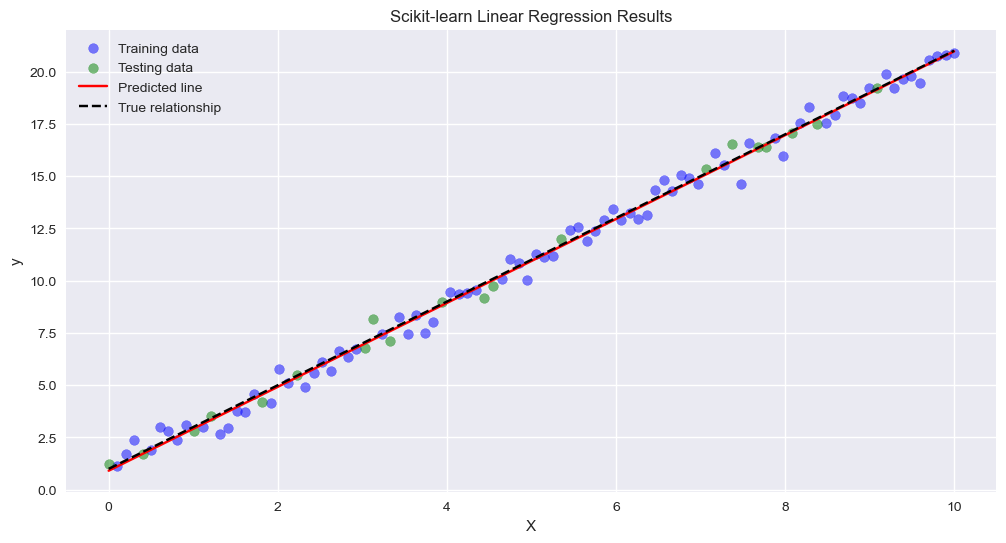

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

# Make predictions
y_pred = model_sklearn.predict(X_test)

# Print the model parameters
# Ensure coefficient is a scalar for formatting
coef_scalar = model_sklearn.coef_[0] if np.isscalar(model_sklearn.coef_[0]) else model_sklearn.coef_[0].item()
print(f"Coefficient (slope): {coef_scalar:.4f}")
intercept_scalar = model_sklearn.intercept_.item() if hasattr(model_sklearn.intercept_, "item") else model_sklearn.intercept_
print(f"Intercept: {intercept_scalar:.4f}")
print(f"\nModel Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# Plot the results
plt.figure(figsize=(12, 6))

# Training data
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training data')
# Testing data
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Testing data')
# Predicted line
plt.plot(X, model_sklearn.predict(X), color='red', label='Predicted line')
# True relationship
plt.plot(X, 2*X + 1, color='black', linestyle='--', label='True relationship')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Scikit-learn Linear Regression Results')
plt.legend()
plt.grid(True)
plt.show()

# 5. Conclusion and Key Takeaways

1. **Linear Regression Basics**:
   - Models linear relationships between variables
   - Uses the equation y = mx + b
   - Simple but powerful for many real-world applications

2. **Implementation Approaches**:
   - Helps understand the underlying mathematics
   - Scikit-learn: Optimized for practical use

3. **Model Evaluation**:
   - R² Score: Measures the proportion of variance explained by the model
   - Mean Squared Error: Measures the average squared difference between predictions and actual values

4. **Best Practices**:
   - Split data into training and testing sets
   - Validate model assumptions
   - Consider feature scaling for multiple features
   - Check for outliers and influential points

Linear regression serves as a foundation for understanding more complex machine learning algorithms and is often a good starting point for many predictive modeling tasks.

# Essential Interview Questions & Answers for Linear Regression

### Basic Concepts

**1. What is linear regression and when should you use it?**
- Linear regression models the relationship between a dependent variable and one or more independent variables
- Use it when you want to:
  - Predict a continuous outcome
  - Understand the relationship between variables
  - Quantify the impact of different features on the target variable
- Examples: predicting house prices, sales forecasting, analyzing relationships between variables

**2. What's the difference between simple and multiple linear regression?**
- Simple linear regression: One independent variable (y = mx + b)
- Multiple linear regression: Multiple independent variables (y = m₁x₁ + m₂x₂ + ... + mₙxₙ + b)
- Both find the best-fitting linear relationship but differ in complexity and applications

**3. What are the key components of a linear regression equation?**
- Dependent variable (y): What we're trying to predict
- Independent variables (x): Features used for prediction
- Coefficients (m): Weight of each feature
- Intercept (b): Base value when all features are zero
- Error term (ε): Accounts for randomness and unmeasured factors

### Model Training

**4. What is the cost function in linear regression and why use MSE?**
- Mean Squared Error (MSE) is the most common cost function
- MSE = (1/n)Σ(y_predicted - y_actual)²
- Benefits of MSE:
  - Penalizes larger errors more heavily
  - Always positive
  - Differentiable (important for gradient descent)
  - Has a single global minimum

**5. Explain gradient descent in detail.**
- An iterative optimization algorithm to find the minimum of the cost function
- Steps:
  1. Start with random parameters
  2. Calculate the gradient (direction of steepest increase)
  3. Take a step in the opposite direction
  4. Repeat until convergence
- Learning rate controls step size

**6. What are the types of gradient descent?**
- Batch Gradient Descent: Uses all data points
- Stochastic Gradient Descent: Uses one point at a time
- Mini-batch Gradient Descent: Uses a subset of points
- Each has trade-offs between computation speed and stability

### Model Evaluation

**7. How do you evaluate a linear regression model?**
- R² (Coefficient of Determination):
  - Measures proportion of variance explained
  - Range: 0 to 1 (higher is better)
- Mean Squared Error (MSE):
  - Average squared differences between predictions and actuals
- Root Mean Squared Error (RMSE):
  - Square root of MSE, in same units as target variable
- Mean Absolute Error (MAE):
  - Average absolute differences

**8. What is the difference between R² and adjusted R²?**
- R²: Doesn't account for number of features
- Adjusted R²:
  - Penalizes adding more features
  - Better for comparing models with different numbers of features
  - Can decrease if unnecessary features are added

**9. What is the training-testing split and why is it important?**
- Splits data into training set (to build model) and testing set (to evaluate)
- Prevents overfitting
- Gives realistic estimate of model performance on new data
- Typical split: 80% training, 20% testing

### Advanced Concepts

**10. What are the assumptions of linear regression?**
- Linearity: Linear relationship between X and y
- Independence: Observations are independent
- Homoscedasticity: Constant variance of errors
- Normality: Errors are normally distributed
- No multicollinearity: Independent variables aren't highly correlated

**11. How do you handle violations of these assumptions?**
- Non-linearity: Transform variables or use polynomial features
- Heteroscedasticity: Use weighted least squares
- Non-normal errors: Transform target variable
- Multicollinearity: Remove correlated features or use regularization

**12. What is regularization and why is it used?**
- Technique to prevent overfitting
- Types:
  - L1 (Lasso): Can zero out coefficients
  - L2 (Ridge): Shrinks coefficients
  - Elastic Net: Combines L1 and L2
- Helps with feature selection and model stability

### Practical Considerations

**13. How do you handle categorical variables?**
- One-hot encoding: Create binary columns for each category
- Label encoding: Convert categories to numbers (ordinal data)
- Effect coding: Similar to one-hot but uses -1, 0, 1
- Consider cardinality and business context

**14. How do you handle missing values?**
- Deletion: Remove rows or columns
- Imputation: Mean, median, mode
- Advanced methods: KNN imputation, regression imputation
- Consider the reason for missing data

**15. What are common pitfalls in linear regression?**
- Extrapolation: Predictions outside training data range
- Outliers: Can significantly affect model
- Overfitting: Too complex model for data
- Underfitting: Too simple model for data
- Not checking assumptions
- Not handling multicollinearity